In [1]:
# ── Cell 1: Solar physics foundation ─────────────────────────────────────────
#
# PHYSICS PRIMER — understanding the solar calculation chain:
#
# 1. SOLAR POWER (W) = Irradiance (W/m²) × Panel Area (m²) × Panel Efficiency
#    Irradiance is how much sunlight energy hits one square metre per second.
#    Standard test condition (STC) = 1000 W/m² (bright midday sun).
#    Indian summer average = 500-700 W/m² over a full day.
#    Panel efficiency = 18-22% for commercial monocrystalline panels.
#
# 2. SOLAR ENERGY PER DAY (Wh) = Solar Power (W) × Peak Sun Hours
#    Peak Sun Hours = equivalent hours of full STC irradiance per day.
#    Assam (NE India) average = 4.5-5.5 peak sun hours per day.
#    This accounts for morning/evening low-angle sun automatically.
#
# 3. RANGE EXTENSION (km) = Solar Energy (Wh) / Vehicle Energy Consumption (Wh/km)
#    E-rickshaw energy consumption ≈ 20-30 Wh/km (loaded, city conditions)
#    Passenger EV energy consumption ≈ 150-200 Wh/km
#
# 4. DISCHARGE DEPTH REDUCTION = Solar Energy / Total Battery Energy per cycle
#    If battery is 2.0 Ahr at 48V = 96 Wh total energy
#    If solar contributes 20 Wh, discharge depth reduces by 20/96 = 20.8%
#
# 5. BATTERY LIFE EXTENSION uses the empirical relationship:
#    Cycle life approximately doubles for every 10% reduction in DoD
#    This is based on the Wöhler curve for lithium-ion cells,
#    consistent with battery manufacturer datasheets.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'Arial',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Vehicle specifications ─────────────────────────────────────────────────────
vehicles = {
    '3-Wheeler (E-Rickshaw)': {
        'battery_voltage':     48,      # Volts — standard e-rickshaw pack
        'battery_capacity_ah': 100,     # Amp-hours — typical lead-acid or LiFePO4
        'energy_consumption':  25,      # Wh/km — loaded city conditions
        'panel_area':          1.2,     # m² — flat roof available area
        'typical_dod':         0.70,    # 70% depth of discharge per cycle
        'color':               '#FF5722',
        'profile_temp':        43,      # °C — tropical India
        'daily_km':            80,      # typical daily route distance
        'peak_sun_hours':      5.0,     # Assam/NE India average
    },
    '4-Wheeler (Passenger EV)': {
        'battery_voltage':     400,     # Volts — standard EV pack
        'battery_capacity_ah': 60,      # Amp-hours — ~24 kWh pack
        'energy_consumption':  175,     # Wh/km — mixed driving
        'panel_area':          2.0,     # m² — roof panel area
        'typical_dod':         0.80,    # 80% depth of discharge per cycle
        'color':               '#2196F3',
        'profile_temp':        24,      # °C — temperate
        'daily_km':            150,     # typical daily commute + errands
        'peak_sun_hours':      4.0,     # temperate climate average
    }
}

# ── Solar calculation function ─────────────────────────────────────────────────
def compute_solar_benefit(vehicle_specs, irradiance_wm2, panel_efficiency=0.20):
    """
    Compute the complete solar energy benefit for a given vehicle
    and irradiance level.
    
    Parameters:
        vehicle_specs:    dict of vehicle parameters
        irradiance_wm2:   solar irradiance in W/m²
        panel_efficiency: decimal efficiency of solar panel (default 20%)
    
    Returns:
        dict of computed solar benefit metrics
    """
    specs = vehicle_specs
    
    # Step 1: Solar power output
    solar_power_w = irradiance_wm2 * specs['panel_area'] * panel_efficiency
    
    # Step 2: Daily solar energy
    daily_solar_wh = solar_power_w * specs['peak_sun_hours']
    
    # Step 3: Range extension
    range_extension_km = daily_solar_wh / specs['energy_consumption']
    
    # Step 4: Battery total energy capacity
    battery_energy_wh = specs['battery_voltage'] * specs['battery_capacity_ah']
    
    # Step 5: Energy needed for daily route without solar
    daily_energy_needed_wh = specs['daily_km'] * specs['energy_consumption']
    
    # Step 6: Discharge depth reduction
    # Solar energy as fraction of battery capacity
    solar_fraction = min(daily_solar_wh / battery_energy_wh, 1.0)
    
    # New DoD with solar assistance
    original_dod = specs['typical_dod']
    new_dod = max(original_dod - solar_fraction, 0.10)  # Minimum 10% DoD
    dod_reduction_pct = (original_dod - new_dod) / original_dod * 100
    
    # Step 7: Battery life extension
    # Empirical relationship: each 10% DoD reduction ≈ 25% more cycles
    # Based on typical LiFePO4 / NMC cycle life curves
    life_extension_factor = (1 + (dod_reduction_pct / 10) * 0.25)
    
    # Step 8: CO2 savings (avoided fossil fuel equivalent)
    # Average Indian grid emission factor: 0.82 kg CO2/kWh
    co2_saved_kg_per_day = (daily_solar_wh / 1000) * 0.82
    
    return {
        'solar_power_w':         solar_power_w,
        'daily_solar_wh':        daily_solar_wh,
        'range_extension_km':    range_extension_km,
        'battery_energy_wh':     battery_energy_wh,
        'solar_fraction':        solar_fraction * 100,  # as percentage
        'original_dod':          original_dod * 100,
        'new_dod':               new_dod * 100,
        'dod_reduction_pct':     dod_reduction_pct,
        'life_extension_factor': life_extension_factor,
        'co2_saved_kg_per_day':  co2_saved_kg_per_day,
    }

# ── Test at standard irradiance (600 W/m² — typical Indian day average) ───────
print("="*65)
print("SOLAR BENEFIT ANALYSIS — Standard Conditions (600 W/m²)")
print("="*65)

for vehicle_name, specs in vehicles.items():
    result = compute_solar_benefit(specs, irradiance_wm2=600)
    print(f"\n{vehicle_name}")
    print(f"  Panel area:              {specs['panel_area']} m²")
    print(f"  Solar power output:      {result['solar_power_w']:.1f} W")
    print(f"  Daily solar energy:      {result['daily_solar_wh']:.1f} Wh")
    print(f"  Range extension:         +{result['range_extension_km']:.1f} km/day")
    print(f"  Battery energy:          {result['battery_energy_wh']:.0f} Wh")
    print(f"  Solar contribution:      {result['solar_fraction']:.1f}% of battery")
    print(f"  DoD reduction:           {result['original_dod']:.0f}% → "
          f"{result['new_dod']:.0f}% ({result['dod_reduction_pct']:.1f}% reduction)")
    print(f"  Battery life extension:  {result['life_extension_factor']:.2f}× "
          f"(+{(result['life_extension_factor']-1)*100:.0f}%)")
    print(f"  CO₂ saved:              {result['co2_saved_kg_per_day']:.3f} kg/day")

print("\n" + "="*65)

SOLAR BENEFIT ANALYSIS — Standard Conditions (600 W/m²)

3-Wheeler (E-Rickshaw)
  Panel area:              1.2 m²
  Solar power output:      144.0 W
  Daily solar energy:      720.0 Wh
  Range extension:         +28.8 km/day
  Battery energy:          4800 Wh
  Solar contribution:      15.0% of battery
  DoD reduction:           70% → 55% (21.4% reduction)
  Battery life extension:  1.54× (+54%)
  CO₂ saved:              0.590 kg/day

4-Wheeler (Passenger EV)
  Panel area:              2.0 m²
  Solar power output:      240.0 W
  Daily solar energy:      960.0 Wh
  Range extension:         +5.5 km/day
  Battery energy:          24000 Wh
  Solar contribution:      4.0% of battery
  DoD reduction:           80% → 76% (5.0% reduction)
  Battery life extension:  1.12× (+12%)
  CO₂ saved:              0.787 kg/day



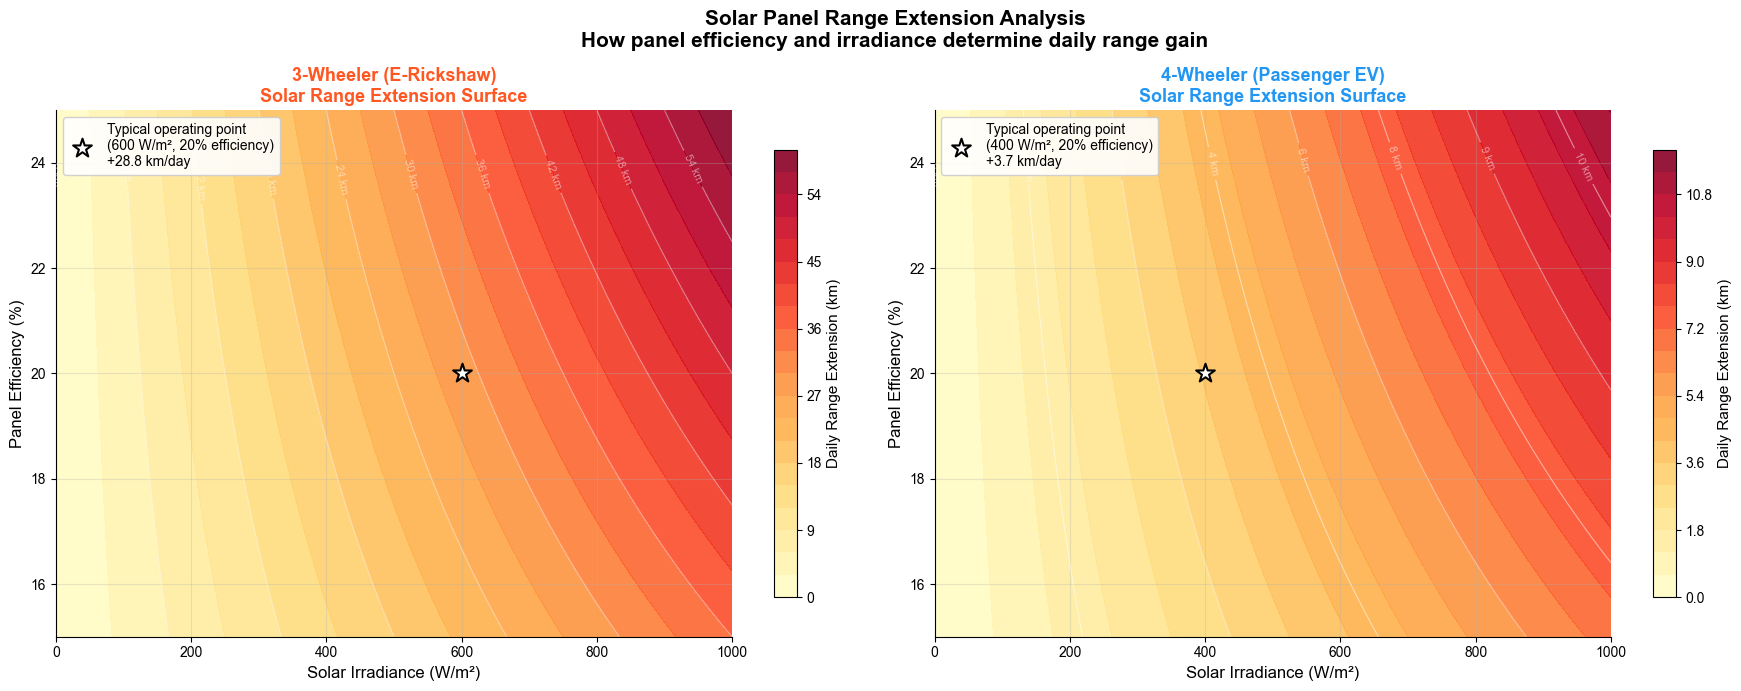

Figure 8 saved: ../figures/10_solar_range_extension_surface.png


In [2]:
# ── Cell 2: Figure 8 — Solar benefit surface plots ────────────────────────────
#
# We create a 2D surface showing how range extension varies across
# two dimensions simultaneously:
#   X-axis: Irradiance (0 to 1000 W/m²) — varies by season and weather
#   Y-axis: Panel efficiency (15% to 25%) — varies by panel quality
#
# This surface plot is what makes the calculator feel like a real
# engineering tool rather than a single-number estimate.

irradiance_range  = np.linspace(0, 1000, 100)    # W/m²
efficiency_range  = np.linspace(0.15, 0.25, 100) # 15% to 25%
irr_grid, eff_grid = np.meshgrid(irradiance_range, efficiency_range)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, (vehicle_name, specs) in enumerate(vehicles.items()):
    ax = axes[idx]
    
    # Compute range extension across the entire grid
    solar_power  = irr_grid * specs['panel_area'] * eff_grid
    daily_energy = solar_power * specs['peak_sun_hours']
    range_ext    = daily_energy / specs['energy_consumption']
    
    # Create filled contour plot
    levels = 20
    cf = ax.contourf(irr_grid, eff_grid * 100, range_ext,
                     levels=levels, cmap='YlOrRd', alpha=0.9)
    
    # Add contour lines with labels
    cs = ax.contour(irr_grid, eff_grid * 100, range_ext,
                    levels=10, colors='white', alpha=0.5, linewidths=0.8)
    ax.clabel(cs, inline=True, fontsize=8, fmt='%.0f km', colors='white')
    
    # Colorbar
    cbar = plt.colorbar(cf, ax=ax, shrink=0.85)
    cbar.set_label('Daily Range Extension (km)', fontsize=11)
    
    # Mark typical operating point
    typical_irr = 600 if idx == 0 else 400  # Higher for tropical
    typical_eff = 0.20
    typical_range = compute_solar_benefit(
        specs, typical_irr, typical_eff)['range_extension_km']
    
    ax.scatter(typical_irr, typical_eff * 100,
               s=200, color='white', zorder=10,
               marker='*', linewidths=1.5,
               edgecolors='black', label=f'Typical operating point\n'
                                         f'({typical_irr} W/m², 20% efficiency)\n'
                                         f'+{typical_range:.1f} km/day')
    
    ax.set_xlabel('Solar Irradiance (W/m²)', fontsize=12)
    ax.set_ylabel('Panel Efficiency (%)', fontsize=12)
    ax.set_title(f'{vehicle_name}\nSolar Range Extension Surface',
                fontsize=13, fontweight='bold',
                color=specs['color'])
    ax.legend(fontsize=10, loc='upper left',
              facecolor='white', framealpha=0.9)

fig.suptitle('Solar Panel Range Extension Analysis\n'
             'How panel efficiency and irradiance determine daily range gain',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/10_solar_range_extension_surface.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved: ../figures/10_solar_range_extension_surface.png")

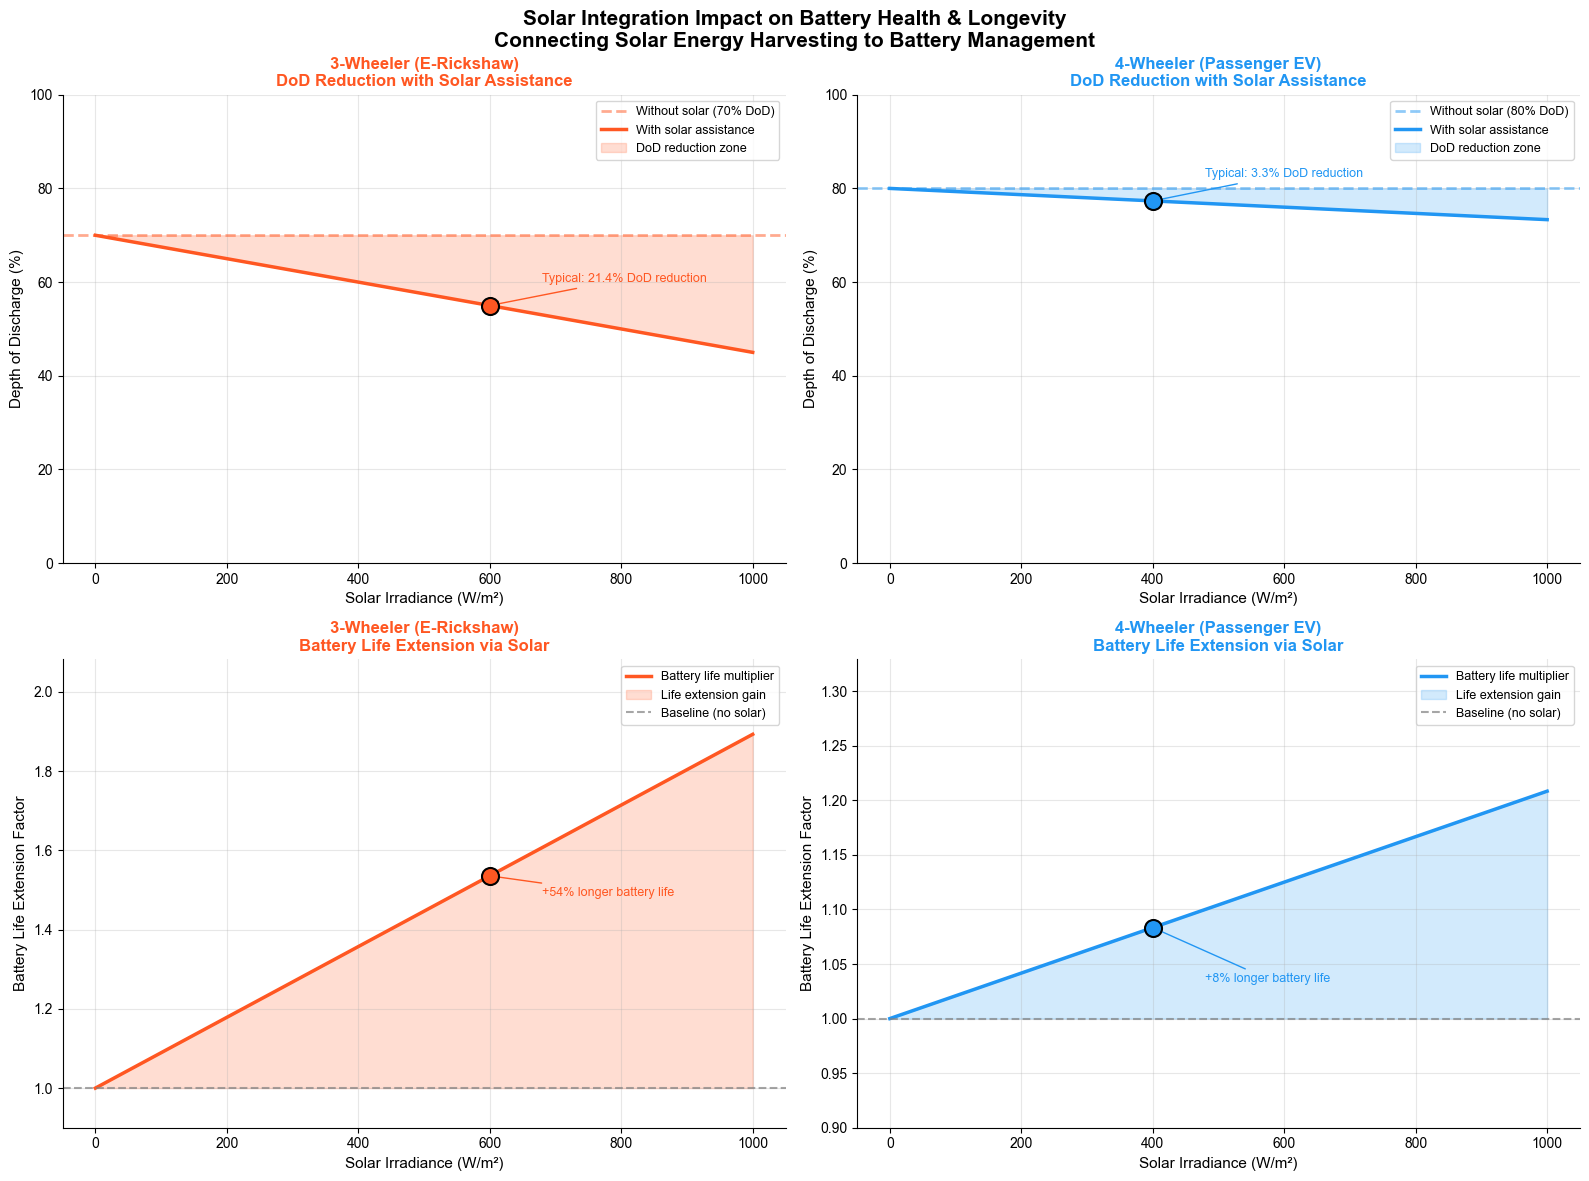

Figure 9 saved: ../figures/11_solar_battery_life_extension.png


In [3]:
# ── Cell 3: Figure 9 — Battery life extension through solar assistance ─────────
#
# This is the most important figure for the ASU internship framing.
# It directly answers: "How does solar integration extend battery life?"
# Connecting your ML battery health prediction to the solar-electric
# hybrid vehicle concept in the internship title.

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

irradiance_values = np.linspace(0, 1000, 200)

for idx, (vehicle_name, specs) in enumerate(vehicles.items()):
    color = specs['color']
    
    # ── Top plots: DoD reduction vs irradiance ────────────────────────────────
    ax_top = axes[0][idx]
    
    dod_values          = []
    dod_reduction_values = []
    life_extension_values = []
    range_ext_values    = []
    
    for irr in irradiance_values:
        result = compute_solar_benefit(specs, irr)
        dod_values.append(result['new_dod'])
        dod_reduction_values.append(result['dod_reduction_pct'])
        life_extension_values.append(result['life_extension_factor'])
        range_ext_values.append(result['range_extension_km'])
    
    # Plot original vs solar-assisted DoD
    ax_top.axhline(y=specs['typical_dod'] * 100,
                   color=color, linestyle='--', linewidth=2,
                   alpha=0.5, label=f'Without solar ({specs["typical_dod"]*100:.0f}% DoD)')
    ax_top.plot(irradiance_values, dod_values,
                color=color, linewidth=2.5,
                label='With solar assistance')
    ax_top.fill_between(irradiance_values,
                        dod_values,
                        specs['typical_dod'] * 100,
                        alpha=0.2, color=color,
                        label='DoD reduction zone')
    
    # Mark typical point
    typical_irr = 600 if idx == 0 else 400
    typical_result = compute_solar_benefit(specs, typical_irr)
    ax_top.scatter(typical_irr, typical_result['new_dod'],
                   s=150, color=color, zorder=10,
                   edgecolors='black', linewidths=1.5)
    ax_top.annotate(f'Typical: {typical_result["dod_reduction_pct"]:.1f}% DoD reduction',
                    xy=(typical_irr, typical_result['new_dod']),
                    xytext=(typical_irr + 80, typical_result['new_dod'] + 5),
                    fontsize=9, color=color,
                    arrowprops=dict(arrowstyle='->', color=color))
    
    ax_top.set_xlabel('Solar Irradiance (W/m²)', fontsize=11)
    ax_top.set_ylabel('Depth of Discharge (%)', fontsize=11)
    ax_top.set_title(f'{vehicle_name}\nDoD Reduction with Solar Assistance',
                    fontsize=12, fontweight='bold', color=color)
    ax_top.legend(fontsize=9)
    ax_top.set_ylim(0, 100)
    
    # ── Bottom plots: Battery life extension vs irradiance ────────────────────
    ax_bot = axes[1][idx]
    
    ax_bot.plot(irradiance_values, life_extension_values,
                color=color, linewidth=2.5,
                label='Battery life multiplier')
    ax_bot.fill_between(irradiance_values, 1.0,
                        life_extension_values,
                        alpha=0.2, color=color,
                        label='Life extension gain')
    ax_bot.axhline(y=1.0, color='gray', linestyle='--',
                   linewidth=1.5, alpha=0.7, label='Baseline (no solar)')
    
    # Typical point annotation
    typical_life = compute_solar_benefit(specs, typical_irr)['life_extension_factor']
    ax_bot.scatter(typical_irr, typical_life,
                   s=150, color=color, zorder=10,
                   edgecolors='black', linewidths=1.5)
    ax_bot.annotate(f'+{(typical_life-1)*100:.0f}% longer battery life',
                    xy=(typical_irr, typical_life),
                    xytext=(typical_irr + 80, typical_life - 0.05),
                    fontsize=9, color=color,
                    arrowprops=dict(arrowstyle='->', color=color))
    
    ax_bot.set_xlabel('Solar Irradiance (W/m²)', fontsize=11)
    ax_bot.set_ylabel('Battery Life Extension Factor', fontsize=11)
    ax_bot.set_title(f'{vehicle_name}\nBattery Life Extension via Solar',
                    fontsize=12, fontweight='bold', color=color)
    ax_bot.legend(fontsize=9)
    ax_bot.set_ylim(0.9, max(life_extension_values) * 1.1)

fig.suptitle('Solar Integration Impact on Battery Health & Longevity\n'
             'Connecting Solar Energy Harvesting to Battery Management',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/11_solar_battery_life_extension.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 9 saved: ../figures/11_solar_battery_life_extension.png")

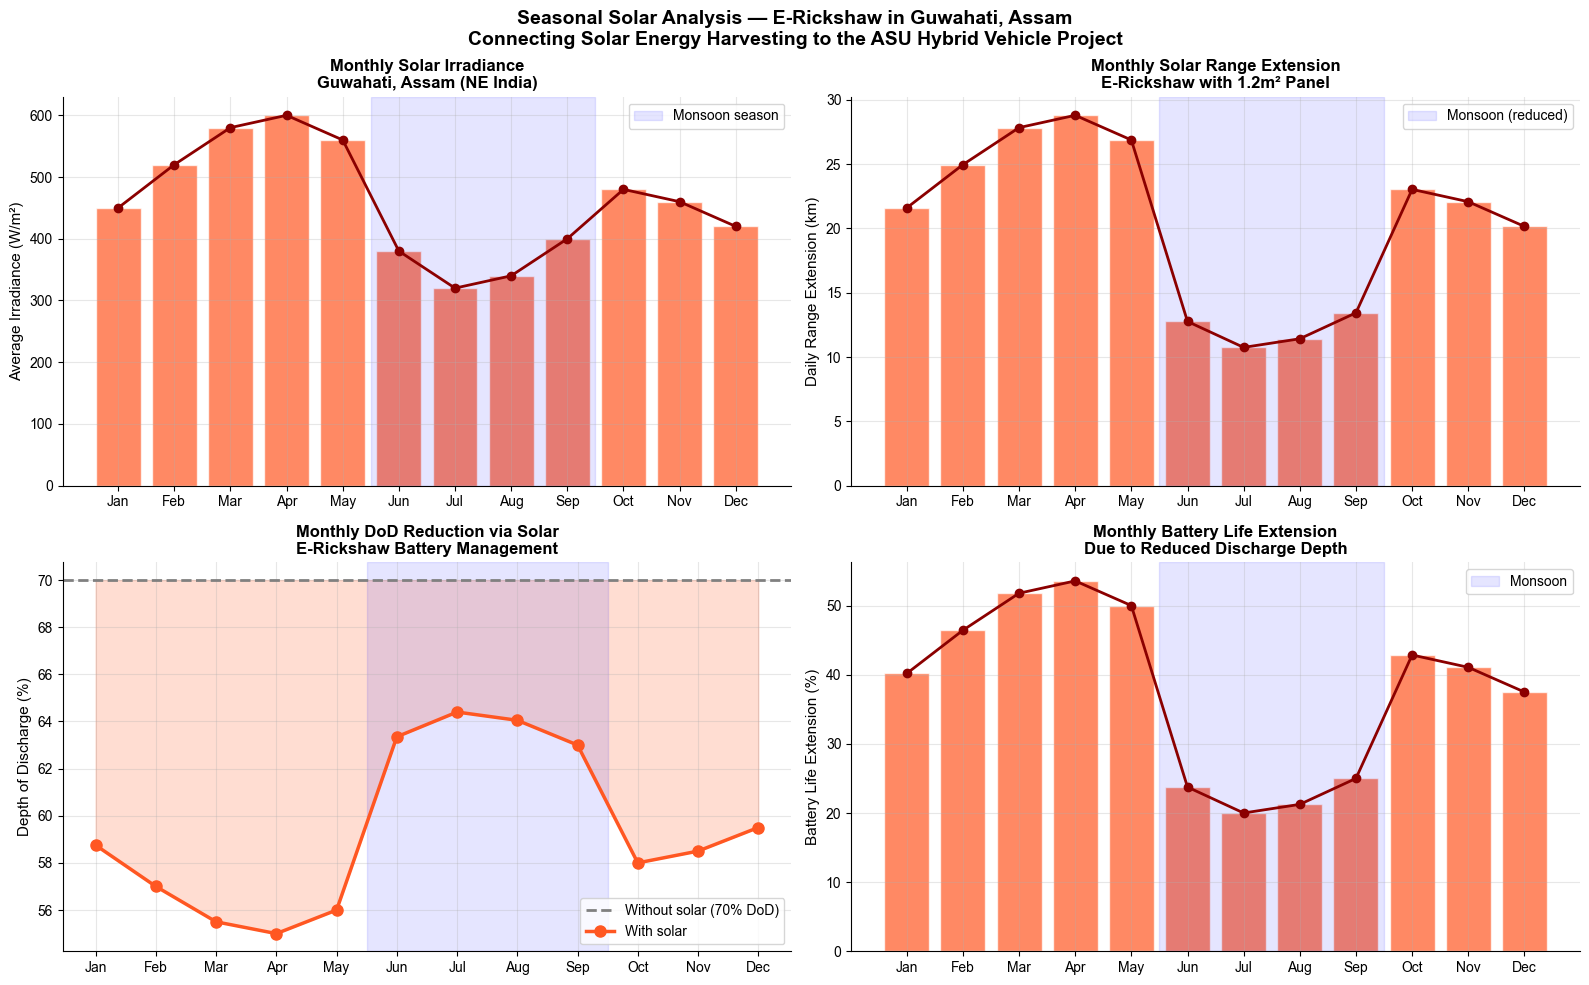


PHASE 5a COMPLETE — SOLAR ANALYSIS SUMMARY

E-Rickshaw (Guwahati, Assam) — Annual averages:
  Avg daily range extension: 20.3 km/day
  Avg DoD reduction:         10.6%
  Avg battery life extension: +37.8%
  Best month:  Apr (+28.8 km/day)
  Worst month: Jul (+10.8 km/day)

Figures saved:
  10_solar_range_extension_surface.png
  11_solar_battery_life_extension.png
  12_seasonal_solar_analysis_guwahati.png


In [4]:
# ── Cell 4: Figure 10 — Seasonal analysis for Indian conditions ───────────────
# It shows how solar benefit varies across Indian seasons for the
# e-rickshaw operating in northeast India (Assam region).

# Monthly average irradiance data for Assam/NE India region (W/m²)
# Source: approximated from NREL Global Solar Atlas data for Guwahati
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Average daily irradiance W/m² for Guwahati, Assam
guwahati_irradiance = [450, 520, 580, 600, 560, 380,
                       320, 340, 400, 480, 460, 420]

# Average temperature °C for Guwahati (affects battery performance)
guwahati_temp = [16, 19, 23, 27, 28, 30,
                 30, 30, 29, 26, 22, 17]

rickshaw_specs = vehicles['3-Wheeler (E-Rickshaw)']

# Compute monthly solar benefits
monthly_range_ext  = []
monthly_life_ext   = []
monthly_dod_new    = []
monthly_solar_wh   = []

for irr, temp in zip(guwahati_irradiance, guwahati_temp):
    # Adjust peak sun hours seasonally
    # Monsoon months (Jun-Sep) have cloud cover reducing effective hours
    if months[guwahati_irradiance.index(irr)] in ['Jun', 'Jul', 'Aug', 'Sep']:
        peak_hours = 3.5
    else:
        peak_hours = 5.0
    
    rickshaw_specs_seasonal = dict(rickshaw_specs)
    rickshaw_specs_seasonal['peak_sun_hours'] = peak_hours
    
    result = compute_solar_benefit(rickshaw_specs_seasonal, irr)
    monthly_range_ext.append(result['range_extension_km'])
    monthly_life_ext.append((result['life_extension_factor'] - 1) * 100)
    monthly_dod_new.append(result['new_dod'])
    monthly_solar_wh.append(result['daily_solar_wh'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
x = range(len(months))
bar_color = '#FF5722'

# Plot 1: Monthly irradiance
ax = axes[0][0]
bars = ax.bar(x, guwahati_irradiance, color=bar_color, alpha=0.7,
              edgecolor='white')
ax.plot(x, guwahati_irradiance, 'o-', color='darkred',
        linewidth=2, markersize=6)
ax.set_xticks(x)
ax.set_xticklabels(months)
ax.set_ylabel('Average Irradiance (W/m²)', fontsize=11)
ax.set_title('Monthly Solar Irradiance\nGuwahati, Assam (NE India)',
            fontsize=12, fontweight='bold')
# Shade monsoon
ax.axvspan(4.5, 8.5, alpha=0.1, color='blue', label='Monsoon season')
ax.legend(fontsize=10)

# Plot 2: Monthly range extension
ax = axes[0][1]
bars = ax.bar(x, monthly_range_ext, color=bar_color, alpha=0.7,
              edgecolor='white')
ax.plot(x, monthly_range_ext, 'o-', color='darkred',
        linewidth=2, markersize=6)
ax.set_xticks(x)
ax.set_xticklabels(months)
ax.set_ylabel('Daily Range Extension (km)', fontsize=11)
ax.set_title('Monthly Solar Range Extension\nE-Rickshaw with 1.2m² Panel',
            fontsize=12, fontweight='bold')
ax.axvspan(4.5, 8.5, alpha=0.1, color='blue', label='Monsoon (reduced)')
ax.legend(fontsize=10)

# Plot 3: Monthly DoD with and without solar
ax = axes[1][0]
ax.axhline(y=rickshaw_specs['typical_dod'] * 100,
           color='gray', linestyle='--', linewidth=2,
           label=f'Without solar ({rickshaw_specs["typical_dod"]*100:.0f}% DoD)')
ax.plot(x, monthly_dod_new, 'o-', color=bar_color,
        linewidth=2.5, markersize=8, label='With solar')
ax.fill_between(x, monthly_dod_new,
                rickshaw_specs['typical_dod'] * 100,
                alpha=0.2, color=bar_color)
ax.set_xticks(x)
ax.set_xticklabels(months)
ax.set_ylabel('Depth of Discharge (%)', fontsize=11)
ax.set_title('Monthly DoD Reduction via Solar\nE-Rickshaw Battery Management',
            fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.axvspan(4.5, 8.5, alpha=0.1, color='blue')

# Plot 4: Monthly battery life extension %
ax = axes[1][1]
bars = ax.bar(x, monthly_life_ext, color=bar_color, alpha=0.7,
              edgecolor='white')
ax.plot(x, monthly_life_ext, 'o-', color='darkred',
        linewidth=2, markersize=6)
ax.set_xticks(x)
ax.set_xticklabels(months)
ax.set_ylabel('Battery Life Extension (%)', fontsize=11)
ax.set_title('Monthly Battery Life Extension\nDue to Reduced Discharge Depth',
            fontsize=12, fontweight='bold')
ax.axvspan(4.5, 8.5, alpha=0.1, color='blue', label='Monsoon')
ax.legend(fontsize=10)

fig.suptitle('Seasonal Solar Analysis — E-Rickshaw in Guwahati, Assam\n'
             'Connecting Solar Energy Harvesting to the ASU Hybrid Vehicle Project',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/12_seasonal_solar_analysis_guwahati.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\n" + "="*60)
print("PHASE 5a COMPLETE — SOLAR ANALYSIS SUMMARY")
print("="*60)
print("\nE-Rickshaw (Guwahati, Assam) — Annual averages:")
print(f"  Avg daily range extension: "
      f"{np.mean(monthly_range_ext):.1f} km/day")
print(f"  Avg DoD reduction:         "
      f"{rickshaw_specs['typical_dod']*100 - np.mean(monthly_dod_new):.1f}%")
print(f"  Avg battery life extension:"
      f" +{np.mean(monthly_life_ext):.1f}%")
print(f"  Best month:  "
      f"{months[np.argmax(monthly_range_ext)]} "
      f"(+{max(monthly_range_ext):.1f} km/day)")
print(f"  Worst month: "
      f"{months[np.argmin(monthly_range_ext)]} "
      f"(+{min(monthly_range_ext):.1f} km/day)")
print("\nFigures saved:")
print("  10_solar_range_extension_surface.png")
print("  11_solar_battery_life_extension.png")
print("  12_seasonal_solar_analysis_guwahati.png")
print("="*60)